<a href="https://colab.research.google.com/github/victoriashushpannikova/nlp_homeworks/blob/main/%D0%B8%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82_nlp_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Цель работы**
Разработать прототип пайплайна на основе одного из предложенных туториалов, интегрировать API языковой модели и представить архитектуру решения в виде блок-схемы.

**Задача:** создать суммаризатор учебника для вывода терминов и краткого содержания глав.

За основу был взят туториал orchestration.ipynb

Подключаем LLM API

In [2]:
!pip install langchain-openai langchain-core -qq

from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

YANDEX_CLOUD_FOLDER = userdata.get('YANDEX_CLOUD_FOLDER')
YANDEX_CLOUD_API_KEY = userdata.get("YANDEX_API_KEY")
YANDEX_CLOUD_MODEL = "yandexgpt"

if YANDEX_CLOUD_FOLDER is None or YANDEX_CLOUD_API_KEY is None:
    print("Один или оба секрета Yandex Cloud не были успешно получены")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 23.3 MB/s eta 0:00:00


Устанавливаем Antiword для обработки файлов формата doc
(Позже программа будет расширена также для обработки pdf-файлов)

In [3]:
# Установка утилиты antiword, необходимой для textract для обработки .doc файлов
!apt-get update && apt-get install -y antiword

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,764 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,026 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-driv

In [26]:
# Установка textract для работы с .doc файлами
!pip install textract -qq

# Установка утилит для работы с PDF файлами через textract
!apt-get update -qq && apt-get install -y poppler-utils -qq

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import textract
import re
import os
import math
from google.colab import files

# Подключение к Yandex GPT
llm = ChatOpenAI(
    model=f"gpt://{YANDEX_CLOUD_FOLDER}/{YANDEX_CLOUD_MODEL}",
    api_key=YANDEX_CLOUD_API_KEY,
    base_url="https://ai.api.cloud.yandex.net/v1",
    temperature=0.7
)

# Максимальная длина текста для LLM в символах (консервативная оценка для 32768 токенов)
MAX_TEXT_LENGTH_FOR_LLM = 90000

# Переводим римские цифры в арабские (в некоторых учебниках главы обозначены римскими цифрами)
def roman_to_int(roman_numeral):
    roman_map = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100, 'D': 500, 'M': 1000}
    int_val = 0
    prev_val = 0
    for char in reversed(roman_numeral.upper()):
        curr_val = roman_map[char]
        if curr_val < prev_val:
            int_val -= curr_val
        else:
            int_val += curr_val
        prev_val = curr_val
    return int_val

# Модель учебника: загрузка и парсинг из файла
def load_and_parse_textbook(file_path):
    chapters = {}
    if not os.path.exists(file_path):
        print(f"Ошибка: Файл учебника не найден по пути: {file_path}")
        return {}

    try:
        raw_text_content = textract.process(file_path, encoding='utf-8').decode('utf-8')
    except Exception as e:
        print(f"Ошибка при чтении файла {file_path}: {e}")
        _, file_extension = os.path.splitext(file_path)
        if file_extension.lower() == '.doc':
            print("Возможно, отсутствует необходимая утилита для обработки .doc. Попробуйте установить: !apt-get update && apt-get install -y antiword")
        elif file_extension.lower() == '.pdf':
            print("Возможно, отсутствует необходимая утилита для обработки .pdf. Попробуйте установить: !apt-get update && apt-get install -y poppler-utils")
        else:
            print("Проверьте формат файла и убедитесь, что установлены все необходимые утилиты для textract.")
        return {}


    normalized_text_original_casing = re.sub(r'\n\s*\n', '\n\n', raw_text_content).strip()
    original_lines = normalized_text_original_casing.split('\n')

    # приводим текст файла к нижнему регистру
    normalized_text_lowercase = normalized_text_original_casing.lower()
    lowercase_lines = normalized_text_lowercase.split('\n')

    ROMAN_NUMERAL_REGEX_STR = r'm{0,3}(?:cm|cd|d?c{0,3})(?:xc|xl|l?x{0,3})(?:ix|iv|v?i{0,3})'
    NUMBER_PATTERN_STR = f"(?:{ROMAN_NUMERAL_REGEX_STR}|\\d+)"

    # Подход 1: Поиск по центрированным строкам в верхнем регистре
    print("Поиск глав по центрированным строкам в ВЕРХНЕМ РЕГИСТРЕ, содержащим 'глава'.")
    hybrid_headings_indices = []

    for i, line in enumerate(original_lines):
        stripped_line = line.strip()
        if not stripped_line:
            continue

        # Поиск по названию "глава"
        if "глава" not in stripped_line.lower():
            continue

        # Поиск по Caps-lock
        alpha_chars = ''.join(filter(str.isalpha, stripped_line))
        if len(alpha_chars) > 0 and (sum(1 for c in alpha_chars if c.isupper()) / len(alpha_chars)) < 0.7:
            continue

        # Проверка расположения (форматирование по центру)
        leading_ws = len(line) - len(line.lstrip())
        trailing_ws = len(line) - len(line.rstrip())

        is_centered = (
            len(stripped_line) > 5 and
            len(stripped_line) < 100 and
            leading_ws > 3 and
            abs(leading_ws - trailing_ws) < 15 and
            len(stripped_line.split()) > 1
        )

        if is_centered:
            hybrid_headings_indices.append(i)

    if hybrid_headings_indices:
        print(f"Найдено {len(hybrid_headings_indices)} глав по гибридному паттерну (all-caps, centered, 'глава').")
        chapter_counter = 1

        if hybrid_headings_indices[0] > 0:
            intro_content = "\n".join(original_lines[0:hybrid_headings_indices[0]]).strip()
            if intro_content:
                chapters[chapter_counter] = f"ВВЕДЕНИЕ\n{intro_content}"
                chapter_counter += 1

        for i, heading_index in enumerate(hybrid_headings_indices):
            heading_text = original_lines[heading_index].strip()

            content_start_index = heading_index + 1
            content_end_index = hybrid_headings_indices[i+1] if i + 1 < len(hybrid_headings_indices) else len(original_lines)

            chapter_content = "\n".join(original_lines[content_start_index:content_end_index]).strip()

            chapters[chapter_counter] = f"{heading_text}\n{chapter_content}"
            chapter_counter += 1
        if chapters:
            return chapters


    # Подход 2: Поиск по паттерну 'глава N:' (регулярные выражения)
    print("Гибридный паттерн не найден. Попытка найти главы по паттерну 'глава N:' (арабские/римские цифры, с опциональным двоеточием и заголовком в нижнем регистре).")
    explicit_chapter_content_pattern = r"(глава\s*(" + NUMBER_PATTERN_STR + r")(?:[:]\s*([^\n]*))?)(.*?)(?=(глава\s*(?:" + NUMBER_PATTERN_STR + r")(?:[:]\s*([^\n]*)?)?|$))"
    explicit_matches = list(re.finditer(explicit_chapter_content_pattern, normalized_text_lowercase, re.DOTALL))

    if explicit_matches:
        for match in explicit_matches:
            chapter_num_str = match.group(2)
            chapter_title = match.group(3)

            content_start_in_lower = match.start(4)
            content_end_in_lower = match.end(4)
            chapter_content_original_casing = normalized_text_original_casing[content_start_in_lower:content_end_in_lower].strip()

            if chapter_title:
                chapter_title = chapter_title.strip()
            else:
                chapter_title = ""

            try:
                chapter_num = int(chapter_num_str)
            except ValueError:
                try:
                    chapter_num = roman_to_int(chapter_num_str.upper())
                except KeyError:
                    print(f"Предупреждение: Не удалось определить номер главы из '{chapter_num_str}'. Пропускаем этот раздел.")
                    continue

            if chapter_title:
                full_chapter_text = f"Глава {chapter_num_str}: {chapter_title.capitalize()}\n{chapter_content_original_casing}"
            else:
                full_chapter_text = f"Глава {chapter_num_str}\n{chapter_content_original_casing}"

            chapters[chapter_num] = full_chapter_text

        if chapters:
            print(f"Найдено {len(chapters)} глав по паттерну 'глава N:'.")
            return chapters

    # Подход 3: Поиск по центрированным строкам (приведенным к нижнему регистру)
    print("Явные главы и гибридный паттерн не найдены. Поиск глав по центрированным строкам (в нижнем регистре).")
    potential_headings_indices = []

    for i, line in enumerate(lowercase_lines):
        stripped_line = line.strip()
        if not stripped_line:
            continue

        leading_ws = len(original_lines[i]) - len(original_lines[i].lstrip())
        trailing_ws = len(original_lines[i]) - len(original_lines[i].rstrip())

        is_potential_heading = (
            len(stripped_line) > 5 and
            len(stripped_line) < 80 and
            leading_ws > 5 and
            (leading_ws >= (len(original_lines[i]) - len(stripped_line)) / 2 - 2) and
            not re.match(r'^\\d+\\.', stripped_line) and
            not re.match(r'^[-—]', stripped_line)
        )

        if is_potential_heading:
            potential_headings_indices.append(i)

    if potential_headings_indices:
        chapter_counter = 1
        if potential_headings_indices[0] > 0:
            intro_content = "\n".join(original_lines[0:potential_headings_indices[0]]).strip()
            if intro_content:
                chapters[chapter_counter] = f"ВВЕДЕНИЕ\n{intro_content}"
                chapter_counter += 1

        for i, heading_index in enumerate(potential_headings_indices):
            heading_text = original_lines[heading_index].strip()
            content_start_index = heading_index + 1
            content_end_index = potential_headings_indices[i+1] if i + 1 < len(potential_headings_indices) else len(original_lines)
            chapter_content = "\n".join(original_lines[content_start_index:content_end_index]).strip()
            full_chapter_text = f"Глава {chapter_counter}: {heading_text.capitalize()}\n{chapter_content}"
            chapters[chapter_counter] = full_chapter_text
            chapter_counter += 1
        if chapters:
            print(f"Найдено {len(chapters)} глав по центрированным строкам.")
            return chapters

    # Если не удалось найти главы
    if not chapters and normalized_text_original_casing.strip():
        chapters[1] = normalized_text_original_casing.strip()
        print("Внимание: Не удалось найти главы по каким-либо паттернам. Весь документ загружен как Глава 1.")
    return chapters

# Возможность загрузить файл учебника
print("Пожалуйста, загрузите файл учебника (например, .doc или .pdf).")
uploaded = files.upload()

if uploaded:
    # Берем имя загруженного файла
    TEXTBOOK_FILE_PATH = list(uploaded.keys())[0]
    print(f"Файл '{TEXTBOOK_FILE_PATH}' успешно загружен.")
else:
    print("Файл не был загружен. Пожалуйста, попробуйте снова.")
    TEXTBOOK_FILE_PATH = None # Ensure TEXTBOOK_FILE_PATH is None if no file is uploaded

TEXTBOOK_CONTENT = {}
if TEXTBOOK_FILE_PATH:
    TEXTBOOK_CONTENT = load_and_parse_textbook(TEXTBOOK_FILE_PATH)

if not TEXTBOOK_CONTENT:
    print("Ошибка: Не удалось загрузить содержимое учебника. Проверьте путь к файлу, его формат и наличие глав.")

# Определяем состояние агента для суммаризатора
class SummaryState(TypedDict):
    chapter_num: int    # Номер главы/параграфа
    raw_text: str       # Извлеченный текст
    key_terms: str      # Ключевые термины
    summary: str        # Итоговый конспект

# Узел 1: Извлечение текста главы
def select_chapter_node(state: SummaryState):
    chapter_num = state['chapter_num']
    text = TEXTBOOK_CONTENT.get(chapter_num, "")
    if not text:
        print(f"Ошибка: Глава {chapter_num} не найдена в учебнике.")
        return {"raw_text": "", "summary": "Глава не найдена.", "key_terms": ""}
    return {"raw_text": text}

# Узел 2: Извлечение ключевых терминов
def extract_key_terms_node(state: SummaryState):
    if not state['raw_text']:
        return {"key_terms": ""}

    text_to_process = state['raw_text']
    # Если текст слишком длинный, обрабатываем только его начало для ключевых терминов
    if len(text_to_process) > MAX_TEXT_LENGTH_FOR_LLM:
        print("Внимание: Текст для извлечения ключевых терминов слишком длинный. Обрабатывается только его начало.")
        text_to_process = text_to_process[:MAX_TEXT_LENGTH_FOR_LLM // 2] # Берем половину лимита для ключей

    prompt = f"Извлеки 5-7 ключевых терминов из следующего текста, перечисли их через запятую: {text_to_process}"
    response = llm.invoke(prompt)
    return {"key_terms": response.content}

# Узел 3: Создание конспекта
def summarize_node(state: SummaryState):
    if not state['raw_text']:
        return {"summary": state['summary']}

    full_text = state['raw_text']
    key_terms = state['key_terms']

    # Проверяем, не слишком ли длинный текст, и если да, применяем chunking
    if len(full_text) > MAX_TEXT_LENGTH_FOR_LLM:
        print("Внимание: Текст для суммаризации слишком длинный. Выполняется поэтапная суммаризация (map-reduce).")

        # Разбиваем текст на чанки
        chunk_size = MAX_TEXT_LENGTH_FOR_LLM # Размер чанка для LLM
        # Убедимся, что есть хотя бы один чанк
        num_chunks = math.ceil(len(full_text) / chunk_size)

        chunked_summaries = []
        for i in range(num_chunks):
            start_index = i * chunk_size
            end_index = min((i + 1) * chunk_size, len(full_text))
            chunk = full_text[start_index:end_index]

            chunk_prompt = f"""Суммируй следующий фрагмент текста, сосредоточься на основных идеях. Избегай повторений.\n            Фрагмент текста: {chunk}\n\nКраткий суммарный фрагмент:"""

            chunk_response = llm.invoke(chunk_prompt)
            chunked_summaries.append(chunk_response.content)
            print(f"Сделана промежуточная суммаризация чанка {i+1}/{num_chunks}")

        # Суммаризируем полученные суммаризации
        combined_summaries_text = "\n\n".join(chunked_summaries)
        print(f"Выполнено {len(chunked_summaries)} промежуточных суммаризаций. Теперь создаем итоговый конспект.")

        # Финальный промпт для объединенных суммаризаций
        prompt = f"""Создай итоговый краткий конспект на основе следующих промежуточных суммаризаций. Включи эти ключевые термины: {key_terms}. Обобщи информацию и сделай ее связной.\n\nПромежуточные суммаризации: {combined_summaries_text}\n\nИтоговый конспект:"""
    else:
        # Исходный промпт для текста в пределах лимита
        prompt = f"""Создай краткий конспект следующей главы учебника. Включи эти ключевые термины: {key_terms}.\nТекст главы: {full_text}\n\nКраткий конспект:"""

    response = llm.invoke(prompt)
    return {"summary": response.content}

# Строим последовательный граф для суммаризатора
workflow = StateGraph(SummaryState)
workflow.add_node("select_chapter", select_chapter_node)
workflow.add_node("extract_key_terms", extract_key_terms_node)
workflow.add_node("summarize", summarize_node)

workflow.add_edge(START, "select_chapter")
workflow.add_edge("select_chapter", "extract_key_terms")
workflow.add_edge("extract_key_terms", "summarize")
workflow.add_edge("summarize", END)

app = workflow.compile()

# Запускаем суммаризатор
# Попробуйте с разными номерами глав (1, 2 или несуществующей, например 3)
chapter_to_summarize = int(input("Введите номер главы для суммаризации: "))

result = app.invoke({
    "chapter_num": chapter_to_summarize,
    "raw_text": "",
    "key_terms": "",
    "summary": ""
})

print(f"=== СУММАРИЗАЦИЯ ГЛАВЫ {chapter_to_summarize} ===")
print(f"\nИсходный текст:\n{result['raw_text'][:1000]}... (обрезано для отображения)") # Обрезаем для вывода
print(f"\nКлючевые термины:\n{result['key_terms']}")
print(f"\nКонспект:\n{result['summary']}")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Пожалуйста, загрузите файл учебника (например, .doc или .pdf).


Saving A_A_Reformatskiy_Vvedenie_v_yazykovedenie.doc to A_A_Reformatskiy_Vvedenie_v_yazykovedenie.doc
Файл 'A_A_Reformatskiy_Vvedenie_v_yazykovedenie.doc' успешно загружен.
Поиск глав по центрированным строкам в ВЕРХНЕМ РЕГИСТРЕ, содержащим 'глава'.
Гибридный паттерн не найден. Попытка найти главы по паттерну 'глава N:' (арабские/римские цифры, с опциональным двоеточием и заголовком в нижнем регистре).
Найдено 8 глав по паттерну 'глава N:'.
Введите номер главы для суммаризации: 2
=== СУММАРИЗАЦИЯ ГЛАВЫ 2 ===

Исходный текст:
Глава ii
33
ЛЕКСИКОЛОГИЯ     33
  § 7. СЛОВО КАК ПРЕДМЕТ ЛЕКСИГОЛОГИИ   33
  § 8. ТИПЫ СЛОВ В ЯЗЫКЕ     40
   ФУНКЦИИ  41
  § 9. РАВНОИМЕННОСТЬ И ЕЕ РАЗНОВИДНОСТИ      43
  § 10. ПОЛИСЕМИЯ 44
  § 11. МЕТАФОРА  45
  § 12. ПЕРЕНОС ПО ФУНКЦИИ   46
§ 13. МЕТОНИМИЯ  47
  § 14. СИНЕКДОХА 48
  § 15. ОМОНИМИЯ  48
  § 16. СИНОНИМЫ  52
  § 17. АНТОНИМЫ  54
  § 18. ТАБУ И ЭВФЕМИЗМЫ     56
  § 19. ЭТИМОЛОГИЯ И «НАРОДНАЯ» ЭТИМОЛОГИЯ    57
  § 20. КОНТЕКСТ И ЭЛЛИПСЫ   60
  § 21.

Программа находит главы не во всех файлах (обычно сложности возникают я форматом pdf). Вероятно, для некоторых случаев стоит дорабатывать код (либо корректировать поиск, либо способы получения доступа к файлу)

# Блок-схема

In [20]:
import graphviz

# Install graphviz (if not already installed)
!pip install graphviz -qq

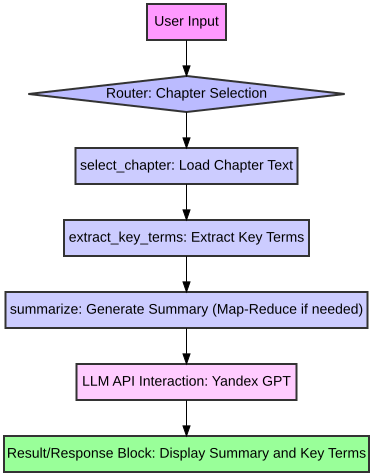

In [21]:
dot_code = """
digraph G {
    rankdir=TD;
    node [shape=box, style=filled, penwidth=2, fontname="Arial"];

    A [label="User Input", fillcolor="#ff99ff", color="#333333"];
    B [label="Router: Chapter Selection", shape=diamond, fillcolor="#bbbbff", color="#333333"];
    C [label="select_chapter: Load Chapter Text", fillcolor="#ccccff", color="#333333"];
    D [label="extract_key_terms: Extract Key Terms", fillcolor="#ccccff", color="#333333"];
    E [label="summarize: Generate Summary (Map-Reduce if needed)", fillcolor="#ccccff", color="#333333"];
    F [label="LLM API Interaction: Yandex GPT", fillcolor="#ffccff", color="#333333"];
    G [label="Result/Response Block: Display Summary and Key Terms", fillcolor="#99ff99", color="#333333"];

    A -> B;
    B -> C;
    C -> D;
    D -> E;
    E -> F;
    F -> G;
}
"""

# Create a Graphviz Source object and render it
graph = graphviz.Source(dot_code)
graph